# **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             confusion_matrix,
                             classification_report,
                             recall_score,
                             precision_score)

print('Everything is loaded Boss')

Everything is loaded Boss


# **Data Exploration**

# *Load the Data*

In [2]:
file_path = input("Enter the File Path: ").replace('\\','\\')
df = pd.read_csv(file_path)
print('Data Loaded boss')

Data Loaded boss


## *Exploration*

In [3]:
print(f"The Dataset have {df.shape[0]} rows and {df.shape[1]} columns with {df.duplicated().sum()} duplicates")

The Dataset have 612 rows and 8 columns with 12 duplicates


In [4]:
df.head()

,machine_age_years,operating_temp_c,vibration_hz,pressure_bar,rpm,days_since_maintenance,error_count_30days,machine_failed
0,18.0,95.2,20.9,12.24,1646.0,255.0,15.0,1
1,9.0,142.5,46.55,2.61,2071.0,252.0,17.0,1
2,13.0,82.8,99.59,2.23,2914.0,173.0,12.0,1
3,19.0,74.3,66.43,7.54,1927.0,315.0,1.0,1
4,11.0,94.2,35.26,13.74,1094.0,206.0,18.0,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   machine_age_years       612 non-null    float64
 1   operating_temp_c        590 non-null    float64
 2   vibration_hz            592 non-null    str    
 3   pressure_bar            612 non-null    float64
 4   rpm                     612 non-null    float64
 5   days_since_maintenance  612 non-null    float64
 6   error_count_30days      612 non-null    float64
 7   machine_failed          612 non-null    int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 41.3 KB


In [6]:
df.describe()

,machine_age_years,operating_temp_c,pressure_bar,rpm,days_since_maintenance,error_count_30days,machine_failed
count,612.000000,590.000000,612.000000,612.000000,612.000000,612.000000,612.000000
mean,9.769608,106.798644,8.848562,1780.129085,194.893791,9.606209,0.516340
std,5.502345,39.026825,20.306962,724.222266,102.565201,5.708422,0.500142
min,-4.000000,60.200000,1.010000,-100.000000,0.000000,0.000000,0.000000
25%,5.000000,81.775000,4.682500,1169.000000,111.000000,5.000000,0.000000
50%,10.000000,107.050000,7.925000,1774.000000,196.000000,10.000000,1.000000
75%,14.000000,129.275000,11.700000,2424.500000,286.000000,15.000000,1.000000
max,19.000000,800.000000,500.000000,2997.000000,364.000000,19.000000,1.000000


In [9]:
print('NaN values in columns')
print(df.isna().sum())

NaN values in columns
machine_age_years          0
operating_temp_c          22
vibration_hz              20
pressure_bar               0
rpm                        0
days_since_maintenance     0
error_count_30days         0
machine_failed             0
dtype: int64


# **Data Cleaning**

## *Crate Copy*

In [10]:
df_copy = df.copy()
print('Copy Created')

Copy Created


## *DataType*

In [12]:
df_copy['vibration_hz'] = df_copy['vibration_hz'].replace('_err','',regex=True).astype('float')

## *Impossible Values*

In [15]:
df_copy.loc[df_copy['machine_age_years']<=0,'machine_age_years'] = np.nan
df_copy.loc[df_copy['rpm']<=0,'rpm'] = np.nan
df_copy.loc[df_copy['days_since_maintenance']<0,'days_since_maintenance'] = np.nan

## *Outliers*

In [16]:
outliers = ['operating_temp_c','pressure_bar','rpm']

for outlier in outliers:
    Q1 = df_copy[outlier].quantile(0.25)
    Q3 = df_copy[outlier].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[outlier] < lower, outlier] = np.nan
    df_copy.loc[df_copy[outlier] > upper, outlier] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## *Duplicates*

In [17]:
print(f"Before Cleaning the dataset have {df_copy.duplicated().sum()} duplicates and after cleaning dataset have {df_copy.drop_duplicates(inplace=True)}")

Before Cleaning the dataset have 12 duplicates and after cleaning dataset have None


## *NaN Values*

In [19]:
print('NaN values in the Dataset have: ')
print(df_copy.isna().sum())
NaN_columns = ['machine_age_years','operating_temp_c','vibration_hz','pressure_bar','rpm']
for col in NaN_columns:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
print('NaN values in the Dataset have after filling is: ')
print(df_copy.isna().sum())

NaN values in the Dataset have: 
machine_age_years          1
operating_temp_c          21
vibration_hz              20
pressure_bar               1
rpm                        1
days_since_maintenance     0
error_count_30days         0
machine_failed             0
dtype: int64
NaN values in the Dataset have after filling is: 
machine_age_years         0
operating_temp_c          0
vibration_hz              0
pressure_bar              0
rpm                       0
days_since_maintenance    0
error_count_30days        0
machine_failed            0
dtype: int64


# **Data preperation**

In [20]:
X = df_copy[['machine_age_years',
             'operating_temp_c',
             'vibration_hz',
             'pressure_bar',
             'rpm',
             'days_since_maintenance',
             'error_count_30days']]

y = df_copy['machine_failed']

print(f"X shape: {X.shape}")
print(f'y Shape: {y.shape}')

X shape: (600, 7)
y Shape: (600,)


In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)


print(f"X_train shape: {X_train.shape}")
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'y_test Shape: {y_test.shape}')

X_train shape: (480, 7)
y_train Shape: (480,)
X_test Shape: (120, 7)
y_test Shape: (120,)


# **Models**

## **Decision Tree**

### *Train*

In [44]:
model = DecisionTreeClassifier(max_depth=3,
                               min_samples_leaf=5,
                               min_samples_split=10,
                               random_state=42)

model.fit(X_train,y_train)

print('Model Trained Boss')

Model Trained Boss


### *Test*

In [45]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[39 12]
 [27 42]]
              precision    recall  f1-score   support

           0       0.59      0.76      0.67        51
           1       0.78      0.61      0.68        69

    accuracy                           0.68       120
   macro avg       0.68      0.69      0.67       120
weighted avg       0.70      0.68      0.68       120



### *Features Importance*

                 Features  Importance
5  days_since_maintenance       0.325
6      error_count_30days       0.260
1        operating_temp_c       0.179
0       machine_age_years       0.167
3            pressure_bar       0.069
2            vibration_hz       0.000
4                     rpm       0.000


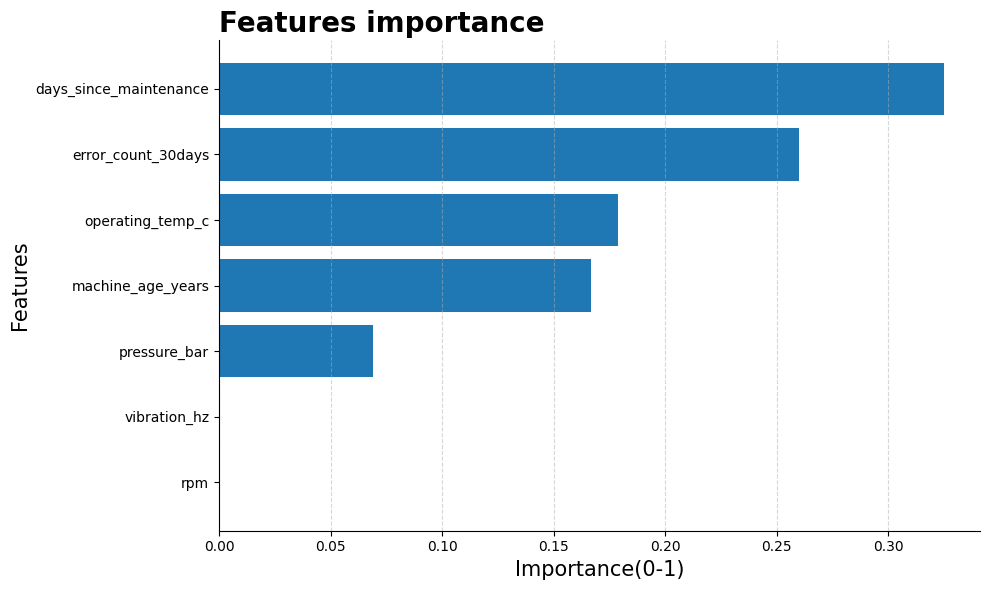

In [46]:
importance = pd.DataFrame({'Features' : X.columns,
                           'Importance': model.feature_importances_.round(3)}).sort_values('Importance',ascending=False)

print(importance)

plt.figure(figsize=(10, 6))

plt.barh(importance['Features'],
         importance['Importance'])

ax = plt.gca()
ax.invert_yaxis()
ax.spines[['right','top']].set_visible(False)
ax.xaxis.grid(True,linestyle='--',alpha=0.5)
plt.xlabel('Importance(0-1)',fontsize=15)
plt.ylabel('Features',fontsize=15)
plt.title('Features importance',weight='bold',fontsize=20,loc='left')
plt.tight_layout()
plt.show()

### *Tree*

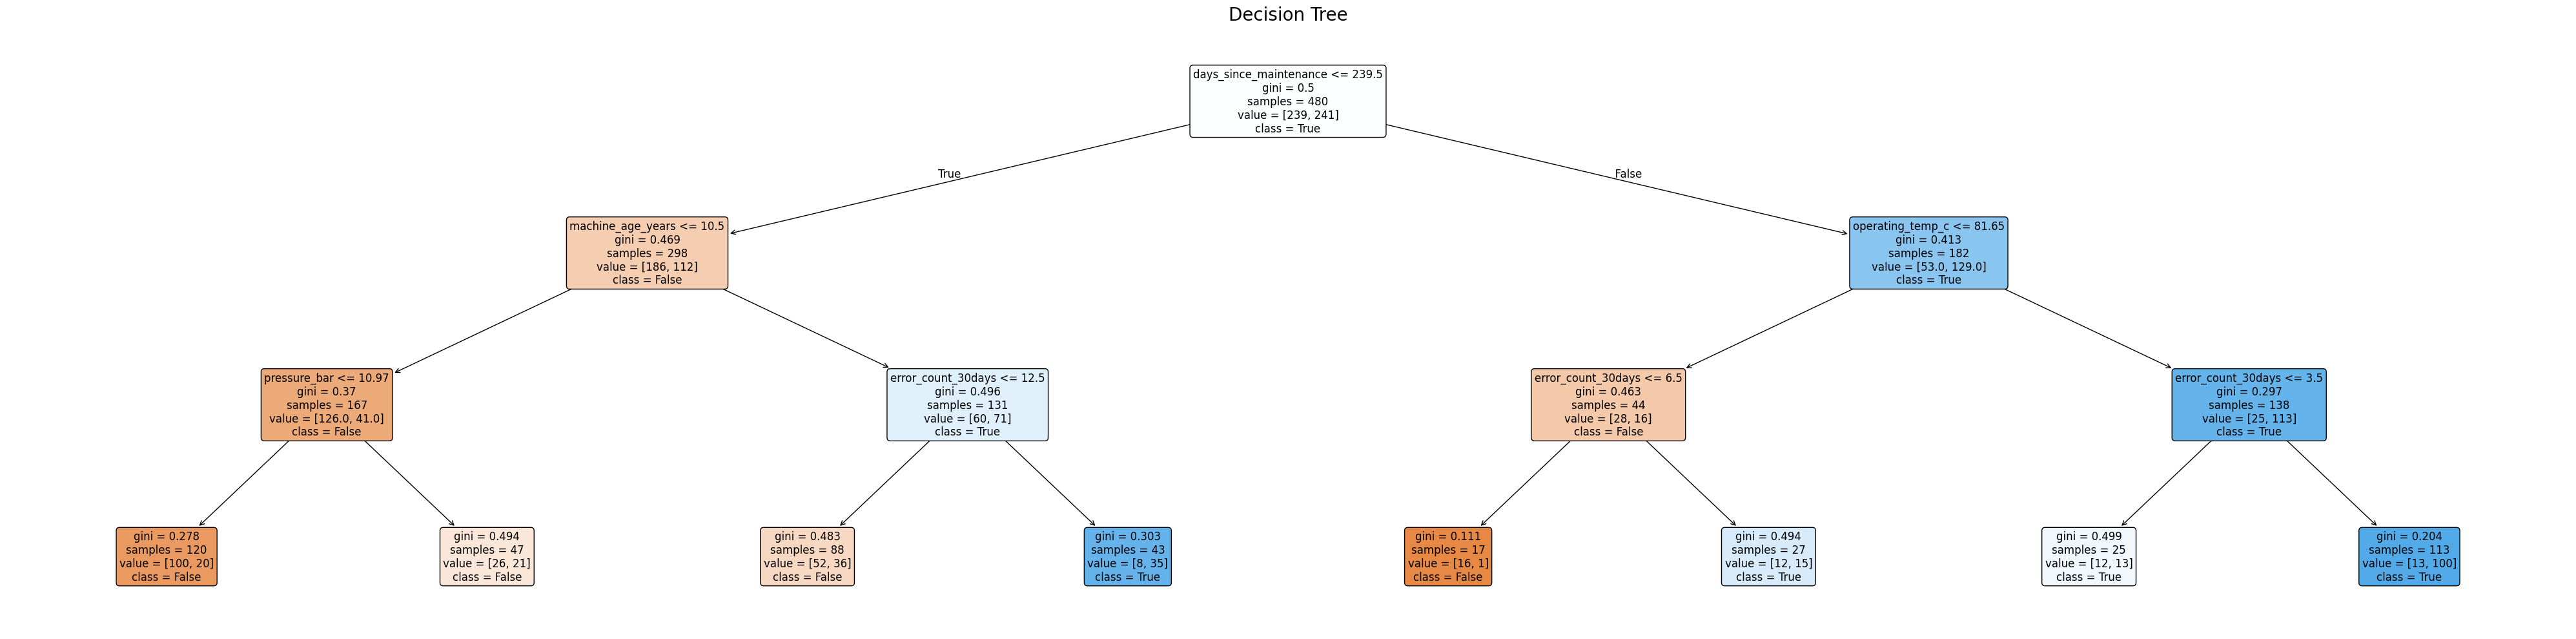

In [48]:
plt.figure(figsize=(40,10))

plot_tree(model,
          feature_names=X.columns.tolist(),
          class_names=['False','True'],
          filled=True,
          rounded=True,
          fontsize=12)

plt.title('Decision Tree',fontsize=20)
plt.tight_layout()
plt.show()

### *Accuracy and gap*

In [49]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.7438
Testing Accuracy:  0.6750
Gap:               0.0687


### *Chart*

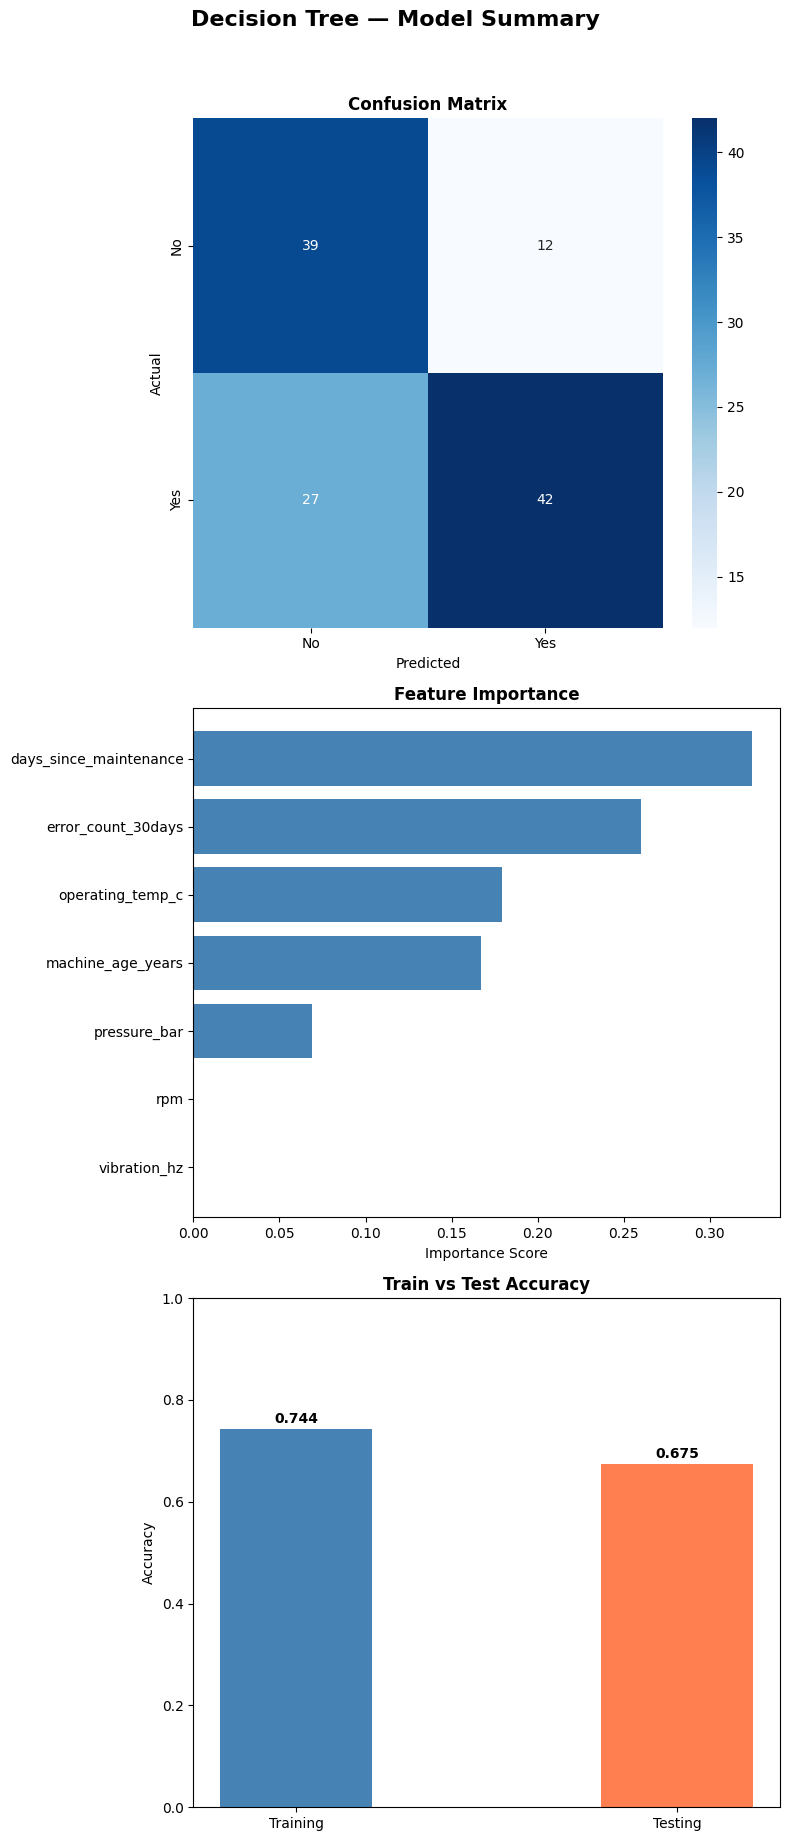

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# --- Plot 2: Feature Importance ---
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance')

axes[1].barh(importance_df['Feature'],
             importance_df['Importance'],
             color='steelblue')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# --- Plot 3: Train vs Test Accuracy ---
labels  = ['Training', 'Testing']
scores  = [train_acc, test_acc]
colors  = ['steelblue', 'coral']

axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', 
                 ha='center', fontweight='bold')

plt.suptitle('Decision Tree — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Logistic Regression**

### *Train*

In [54]:
model = LogisticRegression(max_iter=500)

model.fit(X_train,y_train)

print('Model Trained')

Model Trained


### *Test*

In [55]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

comparission = pd.DataFrame({'Actual':y_test.values,
                             'Pridicted':y_pred,
                             'Probability':y_prob.round(3)})

print(comparission.head())

   Actual  Pridicted  Probability
0       1          1        0.702
1       0          0        0.056
2       1          1        0.955
3       1          0        0.058
4       1          1        0.698


In [57]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[40 11]
 [24 45]]
              precision    recall  f1-score   support

           0       0.62      0.78      0.70        51
           1       0.80      0.65      0.72        69

    accuracy                           0.71       120
   macro avg       0.71      0.72      0.71       120
weighted avg       0.73      0.71      0.71       120



### *Evaluation*

In [58]:
print(f"Accuracy : {round(accuracy_score(y_test,y_pred),4)}")
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1 Score: ", round(f1_score(y_test, y_pred), 4))

Accuracy : 0.7083
Precision: 0.8036
Recall:    0.6522
F1 Score:  0.72


### *Features*

In [59]:
print("Feature Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature:25} → {coef:.4f}")

Feature Coefficients:
  machine_age_years         → 0.1833
  operating_temp_c          → 0.0346
  vibration_hz              → 0.0329
  pressure_bar              → 0.1255
  rpm                       → 0.0009
  days_since_maintenance    → 0.0098
  error_count_30days        → 0.1944


### **Chart**

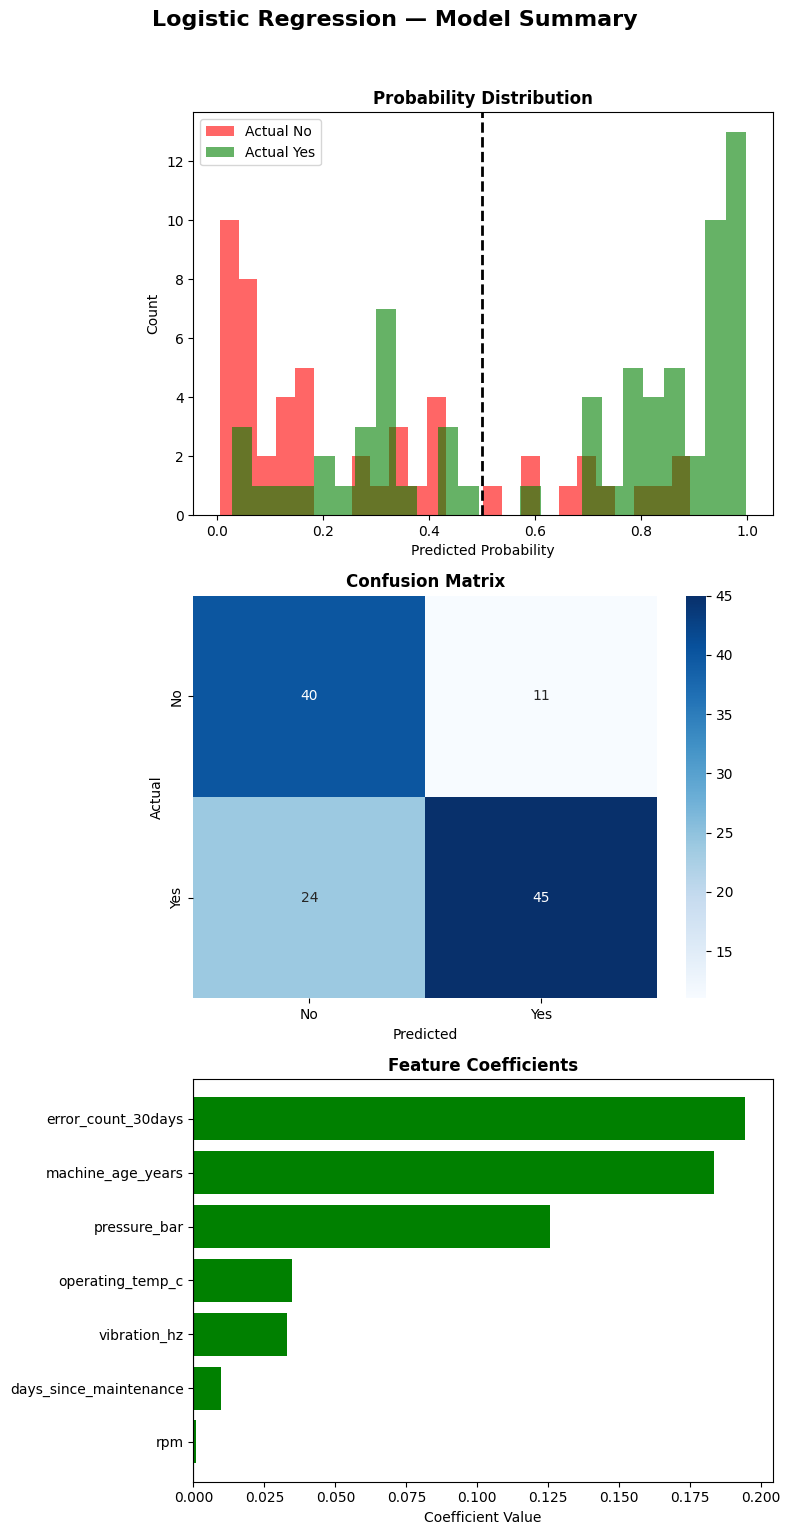

In [60]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

# --- Plot 1: Probability Distribution ---
axes[0].hist(y_prob[y_test == 0], bins=25, alpha=0.6,
             color='red', label='Actual No')
axes[0].hist(y_prob[y_test == 1], bins=25, alpha=0.6,
             color='green', label='Actual Yes')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Plot 2: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# --- Plot 3: Feature Coefficients ---
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')
colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[2].axvline(x=0, color='black', linewidth=1.5)
axes[2].set_title('Feature Coefficients', fontweight='bold')
axes[2].set_xlabel('Coefficient Value')

plt.suptitle('Logistic Regression — Model Summary', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
